In [1]:
pip install feature-engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 7.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [54]:
#necessary libray
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from feature_engine.transformation import LogTransformer
from feature_engine.encoding import OneHotEncoder
from feature_engine.encoding import CountFrequencyEncoder
import category_encoders as ce
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
pd.set_option('display.max_columns',500)

In [3]:
#import the dataset 
data = pd.read_csv('/kaggle/input/datasets/oluwanifemiabimbola/loandata/Loan_Default.csv')
df = data.copy()

In [4]:
#data understanding 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [5]:
#checking missing value
data.isna().sum()

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

In [6]:
# missing value sorting
# filling features missing values with the common label
def filling_the_nas(column):
    return column.fillna(column.mode()[0])

data_for_mean_nas = ['Neg_ammortization',
                     'submission_of_application',
                     'age',
                     'loan_limit',
                     'approv_in_adv',
                     'loan_purpose']

data[data_for_mean_nas] = data[data_for_mean_nas].apply(filling_the_nas)

In [7]:
#dropping the id and age
data = data.drop(['ID','year'],axis=1)

In [8]:
# filling the missing value with the mean of each column
def filling_the_na(column):
    return column.fillna(column.mean())

data_for_mean_na = ['rate_of_interest',
                    'Interest_rate_spread',
                    'Upfront_charges',
                    'term',
                    'property_value',
                    'income',
                    'LTV',
                    'dtir1']

data[data_for_mean_na] = data[data_for_mean_na].apply(filling_the_na)

In [9]:
#checking for the duplicated data
data.duplicated().sum()

np.int64(0)

In [10]:
#data sample
data.sample(5)

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
28203,cf,Female,nopre,type1,p3,l1,nopc,nob/c,246500,3.990000,0.512800,5576.790000,360.0,not_neg,not_int,not_lpsm,428000.0,sb,pr,home,1U,3120.000000,CIB,632,CIB,65-74,to_inst,57.593458,North,direct,0,42.000000
1205,cf,Male,pre,type1,p3,l1,nopc,nob/c,106500,4.045476,0.441656,3224.996127,360.0,not_neg,not_int,not_lpsm,158000.0,sb,pr,home,1U,1740.000000,CIB,538,CIB,65-74,to_inst,67.405063,North,direct,1,44.000000
37872,cf,Joint,nopre,type1,p3,l1,nopc,nob/c,226500,3.875000,1.090800,5403.130000,180.0,not_neg,not_int,not_lpsm,358000.0,sb,pr,home,1U,5280.000000,EXP,532,EXP,55-64,to_inst,63.268156,central,direct,0,22.000000
35104,cf,Joint,nopre,type3,p4,l1,nopc,nob/c,676500,3.500000,-0.357500,559.630000,360.0,not_neg,not_int,not_lpsm,718000.0,sb,pr,home,1U,6957.338876,EXP,803,EXP,65-74,not_inst,94.220056,south,direct,0,37.732932
1707,cf,Female,nopre,type1,p3,l1,nopc,nob/c,366500,3.990000,0.132900,1920.000000,180.0,neg_amm,not_int,not_lpsm,528000.0,sb,pr,home,1U,6900.000000,CRIF,849,CIB,55-64,to_inst,69.412879,North,direct,0,41.000000


In [11]:
#data understanding 
data['loan_limit'].value_counts()

loan_limit
cf     138692
ncf      9978
Name: count, dtype: int64

In [12]:
#more data understanding
data.describe()

,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,1.486700e+05,148670.000000,148670.000000,148670.000000,148670.000000,1.486700e+05,148670.000000,148670.000000,148670.000000,148670.000000,148670.000000
mean,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,1.839093e+05,0.487764,0.445359,2784.133285,58.401029,3.411696e+05,6293.492004,115.875857,37.883839,0.430942,9.652119
min,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,1.965000e+05,3.750000,0.181500,1250.000000,360.000000,2.880000e+05,3840.000000,599.000000,63.297872,0.000000,33.000000
50%,2.965000e+05,4.045476,0.441656,3224.996127,360.000000,4.580000e+05,6000.000000,699.000000,73.026316,0.000000,37.732932
75%,4.365000e+05,4.250000,0.620000,3889.495000,360.000000,5.980000e+05,8280.000000,800.000000,84.722222,0.000000,44.000000
max,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [13]:
#loan distribution within the loan limit
data.groupby('loan_limit')['loan_amount'].mean()

loan_limit
cf     317365.514954
ncf    522270.695530
Name: loan_amount, dtype: float64

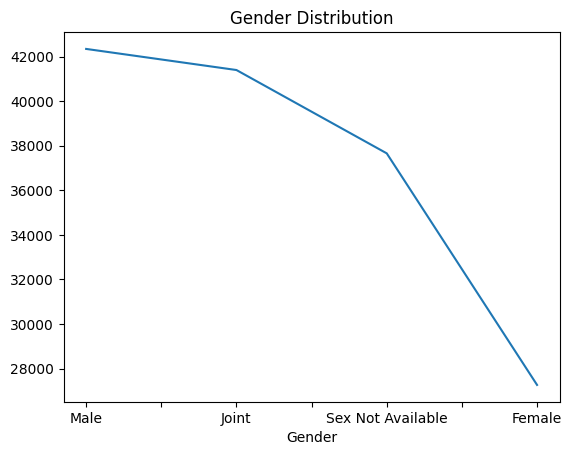

In [14]:
#gender distribution
gender_dist = data['Gender'].value_counts()
gender_dist.plot(kind='line')
plt.title('Gender Distribution')
plt.show()

Text(0.5, 1.0, '% of Approve distribution')

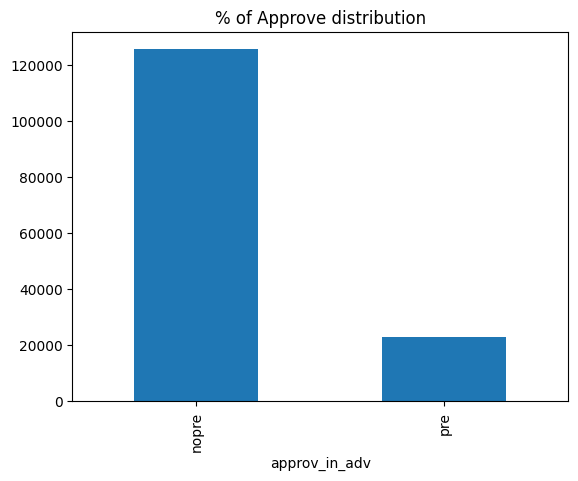

In [15]:
#approvein advance distribution
approve_in = data['approv_in_adv'].value_counts()
approve_in.plot(kind='bar')
plt.title('% of Approve distribution')

In [16]:
#most requested type of loan 
data.groupby('loan_type')['Status'].value_counts()

loan_type  Status
type1      0         87398
           1         25775
type2      0         13590
           1          7172
type3      0         11043
           1          3692
Name: count, dtype: int64

In [17]:
#loan limit and approva rate 
data.groupby('loan_limit')['Status'].value_counts()

loan_limit  Status
cf          0         105367
            1          33325
ncf         0           6664
            1           3314
Name: count, dtype: int64

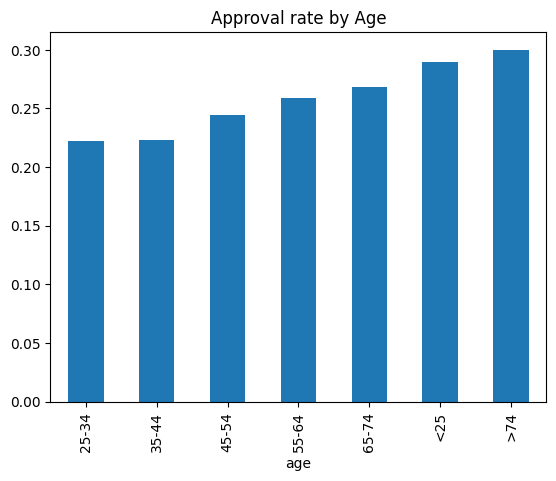

In [18]:
#agegroup and aproval rate
age_group = data.groupby('age')['Status'].mean()
age_group.plot(kind='bar')
plt.title('Approval rate by Age')
plt.show()

In [19]:
#extracting the numerical column
numerical_column = data.select_dtypes(include='number')

In [20]:
numerical_column.columns

Index(['loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score',
       'LTV', 'Status', 'dtir1'],
      dtype='object')

In [21]:
#correlation between the numerical data
numerical_column.corr()

,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
loan_amount,1.000000,-0.124675,-3.114866e-01,0.053403,0.174450,0.687798,0.443258,0.004438,0.036410,-3.682528e-02,0.013634
rate_of_interest,-0.124675,1.000000,6.143210e-01,-0.073862,0.183073,-0.107017,-0.029674,-0.001155,-0.000211,1.952158e-03,0.042404
Interest_rate_spread,-0.311487,0.614321,1.000000e+00,0.032448,-0.137368,-0.291804,-0.112000,-0.001506,0.038529,-2.962990e-17,0.060313
Upfront_charges,0.053403,-0.073862,3.244849e-02,1.000000,-0.047253,0.044650,0.014524,-0.001269,-0.029832,-1.423662e-03,-0.001243
term,0.174450,0.183073,-1.373677e-01,-0.047253,1.000000,0.042761,-0.053317,-0.003149,0.101260,-2.397804e-04,0.103847
property_value,0.687798,-0.107017,-2.918041e-01,0.044650,0.042761,1.000000,0.387084,0.002303,-0.215102,-3.952952e-02,-0.055501
income,0.443258,-0.029674,-1.119996e-01,0.014524,-0.053317,0.387084,1.000000,0.000777,-0.028868,-6.369843e-02,-0.253248
Credit_Score,0.004438,-0.001155,-1.506292e-03,-0.001269,-0.003149,0.002303,0.000777,1.000000,-0.005244,4.003694e-03,-0.000286
LTV,0.036410,-0.000211,3.852892e-02,-0.029832,0.101260,-0.215102,-0.028868,-0.005244,1.000000,3.146519e-02,0.071577
Status,-0.036825,0.001952,-2.962990e-17,-0.001424,-0.000240,-0.039530,-0.063698,0.004004,0.031465,1.000000e+00,0.061290


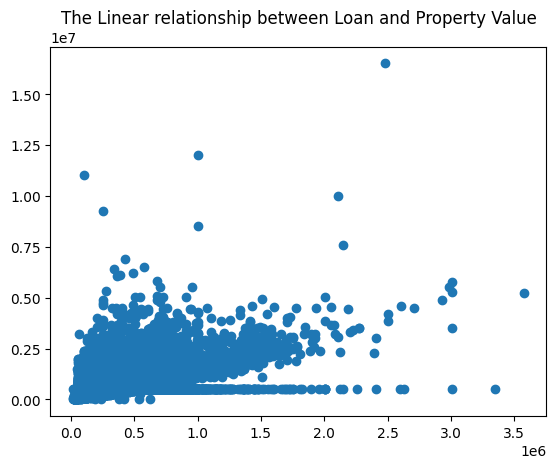

In [22]:
#feature relationship
plt.scatter(data=numerical_column, x='loan_amount', y='property_value')
plt.title('The Linear relationship between Loan and Property Value')
plt.show()

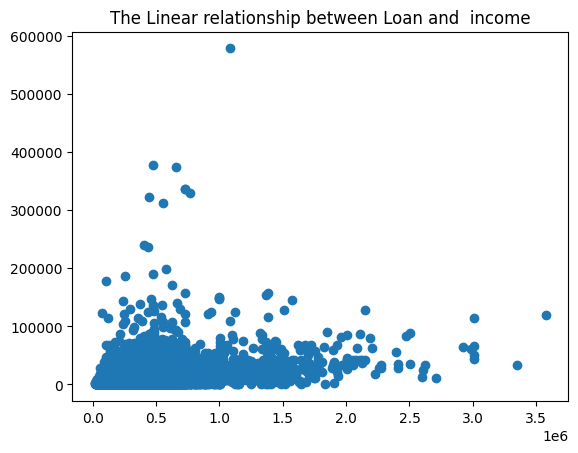

In [23]:
#feature relationship
plt.scatter(data=numerical_column, x='loan_amount', y='income')
plt.title('The Linear relationship between Loan and  income')
plt.show()

In [24]:
numerical_column.columns

Index(['loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score',
       'LTV', 'Status', 'dtir1'],
      dtype='object')

<Axes: >

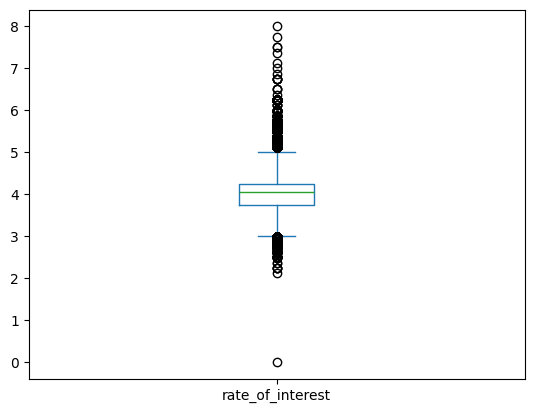

In [25]:
#numerical data distributions
numerical_column['rate_of_interest'].plot(kind='box')

<Axes: ylabel='Frequency'>

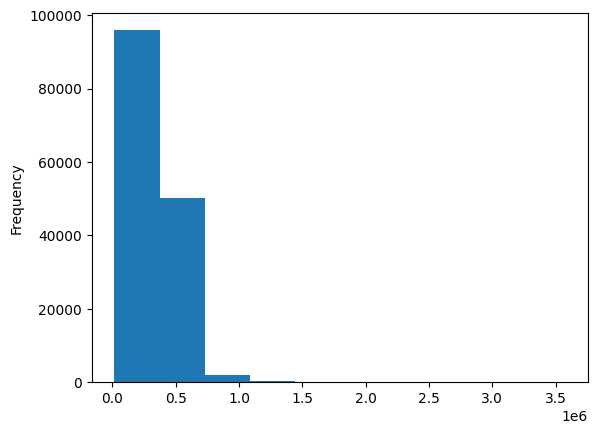

In [26]:
#numerical data distribution
numerical_column['loan_amount'].plot(kind='hist')

<Axes: >

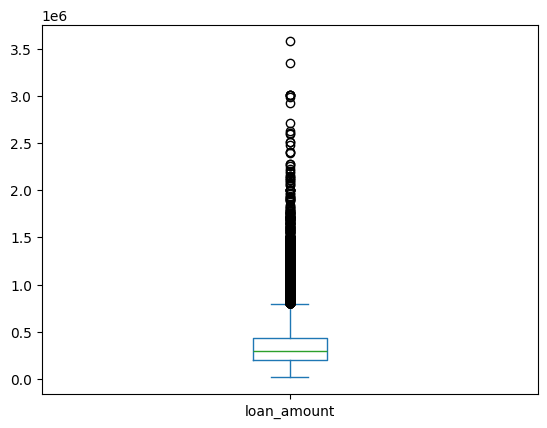

In [27]:
#numerical data distribution
numerical_column['loan_amount'].plot(kind='box')

In [28]:
num = data.select_dtypes(include='number')

In [29]:
#chekcing the skew
num.skew()

loan_amount               1.666998
rate_of_interest          0.447033
Interest_rate_spread      0.323430
Upfront_charges           2.048280
term                     -2.175122
property_value            4.838532
income                   17.866208
Credit_Score              0.004767
LTV                     127.249474
Status                    1.176762
dtir1                    -0.602502
dtype: float64

In [30]:
#splitting the data set
X = data.drop('Status',axis=1)
y = data['Status']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [32]:
#so many outlier , sorting with IQR
numerical_column = ['rate_of_interest',
                    'loan_amount',
                    'Credit_Score',
                    'Interest_rate_spread', 
                    'Upfront_charges', 
                    'term', 
                    'property_value', 
                    'income', 
                    'LTV', 
                    'dtir1']

Q1 = X_train[numerical_column].quantile(0.25)
Q3 = X_train[numerical_column].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (X_train[numerical_column] < lower_bound) | (X_train[numerical_column] > upper_bound)

print("Outlier count per column:")
print(outliers.sum())

Outlier count per column:
rate_of_interest         4610
loan_amount              1291
Credit_Score                0
Interest_rate_spread     7709
Upfront_charges          6015
term                    18077
property_value           4438
income                   5152
LTV                      3065
dtir1                    3661
dtype: int64


In [33]:
# capping the outliers using Winsorization
for col in numerical_column:
    X_train[col] = X_train[col].clip(lower=lower_bound[col], upper=upper_bound[col])
    X_test[col] = X_test[col].clip(lower=lower_bound[col], upper=upper_bound[col])

print("Outliers have been capped successfully!")

Outliers have been capped successfully!


<Axes: >

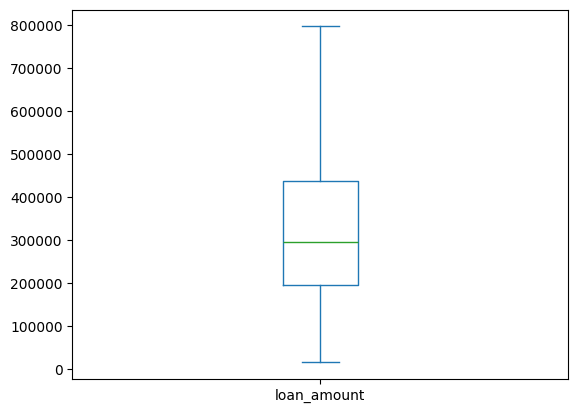

In [34]:
#checking the loan amount for outliers
X_train['loan_amount'].plot(kind='box')

In [35]:
#checking the skewed data after capping the outliers
X_train_num = X_train.select_dtypes(include='number')
X_train_num.skew()

loan_amount             0.682677
rate_of_interest        0.112574
Interest_rate_spread    0.181734
Upfront_charges         0.502773
term                    0.000000
property_value          0.749328
income                  0.778404
Credit_Score            0.007325
LTV                    -0.529994
dtir1                  -0.291589
dtype: float64

In [36]:
X_train.head(1)

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,dtir1
134723,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,186500,4.5,0.8116,2150.0,360.0,not_neg,not_int,not_lpsm,258000.0,sb,pr,home,1U,6600.0,EXP,616,CIB,65-74,to_inst,72.286822,south,direct,44.0


In [37]:
X_train['Security_Type'].value_counts()

Security_Type
direct      99589
Indriect       19
Name: count, dtype: int64

In [38]:
#encoding the categorical data for the onehot encoder
one_hot_encoder = OneHotEncoder(
    variables=['Gender','loan_type',
              'loan_purpose','occupancy_type',
              'total_units','credit_type','age','Region'],
    drop_last=True)

one_hot_encoder.fit(X_train)
X_train = one_hot_encoder.transform(X_train)
X_test = one_hot_encoder.transform(X_test)

print(X_train.head())

       loan_limit approv_in_adv Credit_Worthiness open_credit  \
134723         cf         nopre                l1        nopc   
95172          cf         nopre                l1        nopc   
125573         cf         nopre                l1        nopc   
37443          cf         nopre                l1        nopc   
115897         cf         nopre                l1        nopc   

       business_or_commercial  loan_amount  rate_of_interest  \
134723                  nob/c       186500          4.500000   
95172                   nob/c       176500          5.000000   
125573                  nob/c       306500          3.500000   
37443                   nob/c       206500          4.045476   
115897                  nob/c       386500          3.990000   

        Interest_rate_spread  Upfront_charges   term Neg_ammortization  \
134723              0.811600      2150.000000  360.0           not_neg   
95172               1.278088      2837.800000  360.0           not_neg   
12

In [39]:
X_train.columns

Index(['loan_limit', 'approv_in_adv', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'Secured_by', 'income', 'Credit_Score',
       'co-applicant_credit_type', 'submission_of_application', 'LTV',
       'Security_Type', 'dtir1', 'Gender_Sex Not Available', 'Gender_Female',
       'Gender_Joint', 'loan_type_type1', 'loan_type_type3', 'loan_purpose_p3',
       'loan_purpose_p4', 'loan_purpose_p1', 'occupancy_type_pr',
       'occupancy_type_ir', 'total_units_1U', 'total_units_2U',
       'total_units_3U', 'credit_type_EXP', 'credit_type_CRIF',
       'credit_type_CIB', 'age_65-74', 'age_45-54', 'age_55-64', 'age_25-34',
       'age_>74', 'age_35-44', 'Region_south', 'Region_North',
       'Region_central'],
      dtype='object')

In [40]:
#encoding the categorical data for the binary encoder
binary_encoder = ce.BinaryEncoder(cols=['loan_limit','approv_in_adv',
                                        'Credit_Worthiness','open_credit',
                                        'business_or_commercial',
                                         'Neg_ammortization',
                                         'interest_only',
                                         'lump_sum_payment',
                                         'construction_type',
                                         'Secured_by','Security_Type',
                                         'co-applicant_credit_type',
                                        'submission_of_application'],
                                  return_df=True,)
#fit the transform on the training and test data
binary_encoder.fit(X_train)
X_train = binary_encoder.transform(X_train)
X_test = binary_encoder.transform(X_test)

print(X_train.head())

        loan_limit_0  loan_limit_1  approv_in_adv_0  approv_in_adv_1  \
134723             0             1                0                1   
95172              0             1                0                1   
125573             0             1                0                1   
37443              0             1                0                1   
115897             0             1                0                1   

        Credit_Worthiness_0  Credit_Worthiness_1  open_credit_0  \
134723                    0                    1              0   
95172                     0                    1              0   
125573                    0                    1              0   
37443                     0                    1              0   
115897                    0                    1              0   

        open_credit_1  business_or_commercial_0  business_or_commercial_1  \
134723              1                         0                         1   
95172     

In [41]:
# #dropping the year and age column
# X_train = X_train.drop(['ID'],axis =1)
#X_test = X_test.drop(['ID'],axis =1)

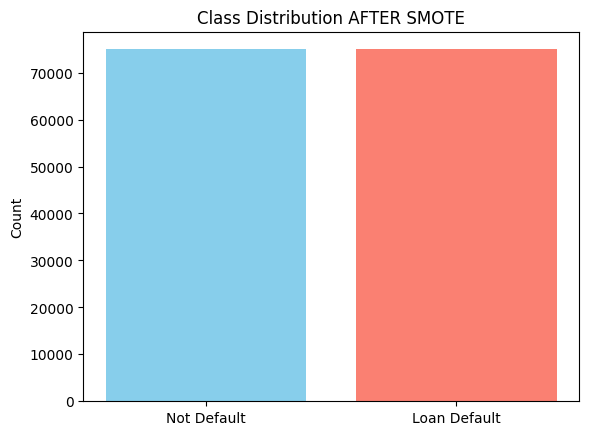

In [42]:
#using smote to sort Imbalance dataset
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values,
        color=['skyblue','salmon'])
plt.xticks([0,1], ['Not Default', 'Loan Default'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

In [43]:
# #hyperparameter tuning 
# #logistic regression paramter to tune 
# grid={
#     'C':[0.001, 0.01,0.1,10],
#     'penalty' : ['l1','l2'],
#     'solver' : ['saga'],
#     'tol' : [1e-4, 1e-3],
#     'max_iter':[100,500]
#     }

In [44]:
# estimators = LogisticRegression()
# gs=RandomizedSearchCV(estimator= estimators,
#                       param_distributions=grid, 
#                       n_iter = 20,
#                       cv=5,
#                       n_jobs = -1,
#                       scoring = 'f1',
#                       random_state = 42) 
# #sampling of the data
# X_sample, y_sample =resample(X_train_sm,y_train_sm,
#                              n_samples = 500,random_state = 42)
# gs= gs.fit(X_sample, y_sample)
# best_params = gs.best_params_
# best_score = gs.best_score_
# print(best_params)
# print(best_score)

In [45]:
#feature scaling
scaler = StandardScaler()
X_train_sm = scaler.fit_transform(X_train_sm)
X_test_sm = scaler.transform(X_test)

In [46]:
#fitting logistic
model =LogisticRegression(random_state=42,
                          solver = 'saga',
                          C= 0.01,
                          penalty = 'l1',
                          max_iter=500,
                          tol = 0.0001)
model.fit(X_train_sm,y_train_sm)

LogisticRegression(C=0.01, max_iter=500, penalty='l1', random_state=42,
                   solver='saga')

In [47]:
y_pred_sm = model.predict(X_test_sm)
print("Accuracy:", round(accuracy_score(y_test, y_pred_sm)*100, 2), "%\n")
print('ROC-AUC:',roc_auc_score(y_test,y_pred_sm))
print("Classification Report:\n", classification_report(y_test, y_pred_sm))

Accuracy: 86.84 %

ROC-AUC: 0.7452108088874388
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.99      0.92     37056
           1       0.92      0.50      0.65     12006

    accuracy                           0.87     49062
   macro avg       0.89      0.75      0.79     49062
weighted avg       0.88      0.87      0.85     49062



In [48]:
# Compare train vs test performance for overfitting 
y_train_pred = model.predict(X_train_sm)
print("Train accuracy:", accuracy_score(y_train_sm, y_train_pred))
print("Test accuracy:", accuracy_score(y_test, y_pred_sm))

Train accuracy: 0.9098299433144381
Test accuracy: 0.8684113978231626


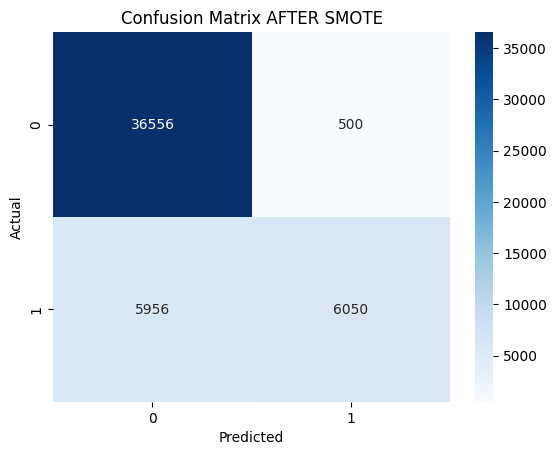

In [49]:
#confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_sm), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix AFTER SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [50]:
#cross validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X_train_sm, y_train_sm, cv=5)
scores
print(scores)
print(scores.mean())

[0.72570857 0.82874291 0.98626209 0.98886295 0.98756252]
0.9034278092697565


In [59]:
# #improving the model precision by using shap to understand the feature ,
# #using shap
# Convert numpy array to DataFrame first
# Get column names from original X_train (before SMOTE)
feature_names = X_train.columns.tolist()

# Convert both to DataFrame using original column names
X_train_sm_df = pd.DataFrame(X_train_sm, columns=feature_names)
X_test_sm_df = pd.DataFrame(X_test_sm, columns=feature_names)

# Now sample works
X_test_sample = X_test_sm_df.sample(500, random_state=42)


explainer = shap.LinearExplainer(model, X_train_sm)

# Calculate SHAP values on the sample
shap_values = explainer(X_test_sample)

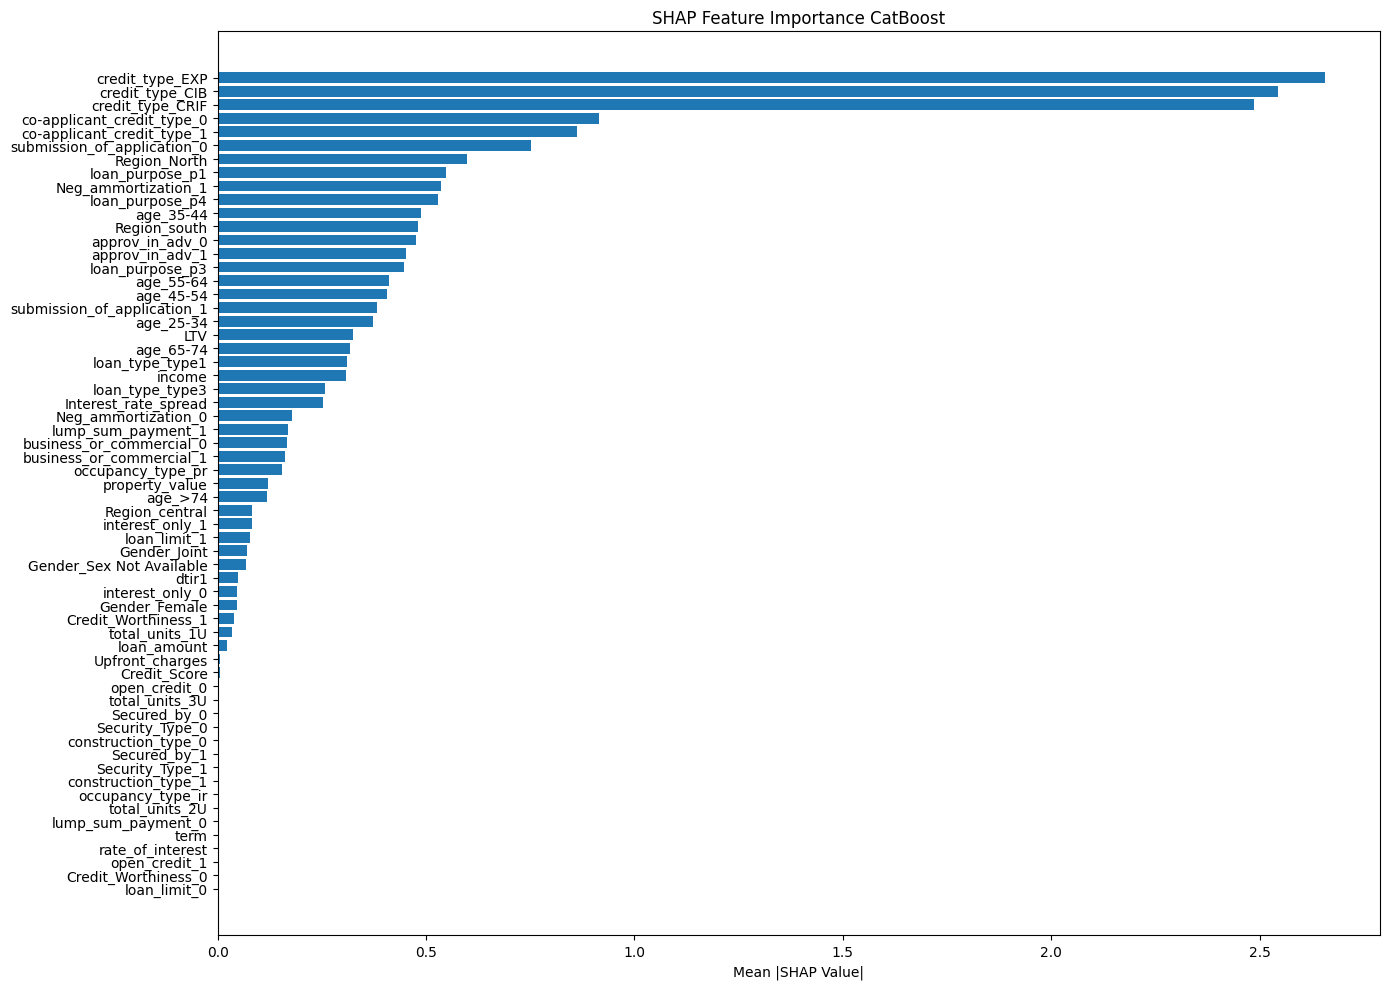

In [61]:
# Get mean absolute SHAP values
vals = np.abs(shap_values.values).mean(axis=0)  

feature_names = X_test_sm_df.columns.tolist()  

# Create dataframe and sort
shap_df = pd.DataFrame({
    'feature': feature_names,
    'importance': vals
}).sort_values('importance', ascending=True)

# Plot
plt.figure(figsize=(14, 10))
plt.barh(shap_df['feature'], shap_df['importance'])
plt.title('SHAP Feature Importance CatBoost')
plt.xlabel('Mean |SHAP Value|')
plt.tight_layout()
plt.show()

In [62]:
import  joblib

joblib.dump(model, 'logisticloan.pkl')

['logisticloan.pkl']